In [160]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

In [161]:
data = yf.download("BTC-USD", "2015-01-01", "2026-01-01")
data = data.reset_index()[['Close']]  # only price
print("BTC rows:", len(data))

/tmp/ipython-input-1808952641.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("BTC-USD", "2015-01-01", "2026-01-01")
[*********************100%***********************]  1 of 1 completed

BTC rows: 4018


In [162]:
fg = pd.read_csv('fear_greed.csv')
fg_value = fg.iloc[:,1].values  # take index values only
fg_value = fg_value[:len(data)]  # truncate if longer than BTC
if len(fg_value) < len(data):    # pad with 0.5 if shorter
    fg_value = np.append(fg_value, [0.5]*(len(data)-len(fg_value)))

fg_value = fg_value.astype(float)/100  # scale 0-1
print("Sentiment length:", len(fg_value))


Sentiment length: 4018


In [163]:
dataset = np.column_stack((data['Close'].values, fg_value))

In [165]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(dataset)

In [166]:
base_days = 100
x, y = [], []
for i in range(base_days, len(scaled_data)):
    x.append(scaled_data[i-base_days:i])
    y.append(scaled_data[i,0])  # predict price
x, y = np.array(x), np.array(y)


In [167]:
model = Sequential()
model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(x.shape[1], x.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 100, 50)        │        10,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,851 (120.51 KB)

 Trainable params: 30,851 (120.51 KB)

 Non-trainable params: 0 (0.00 B)

In [168]:
model.fit(x, y, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 0.0376
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - loss: 0.0023
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - loss: 0.0020
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - loss: 0.0022
Epoch 5/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - loss: 0.0018
Epoch 6/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - loss: 0.0020
Epoch 7/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 13s 102ms/step - loss: 0.0018
Epoch 8/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - loss: 0.0018
Epoch 9/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - loss: 0.0016
Epoch 10/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - loss: 0.0016
Epoch 11/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - loss: 0.0013
Epoch 12/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - loss: 0.0015
Epoch 13/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - loss: 0.0014
Epoch 14/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - loss: 0.0015
Epoch 15/50
123/123 ━━━━━━━━

In [169]:
pred_scaled = model.predict(x)
pred_price = scaler.inverse_transform(
    np.hstack([pred_scaled, scaled_data[base_days:,1].reshape(-1,1)])
)[:,0]

123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step


In [174]:
future_days = 30
last_sequence = scaled_data[-base_days:].copy()
last_sentiment = last_sequence[-1,1]  # last known sentiment

# ---------------- Use actual FG values if available ----------------
fg_future = fg.iloc[len(data):len(data)+future_days,1].values if len(fg) > len(data) else np.array([])
fg_future = np.array(fg_future, dtype=float)/100  # scale 0-1
if len(fg_future) < future_days:
    fg_future = np.append(fg_future, [last_sentiment]*(future_days - len(fg_future)))

future_sentiment = fg_future
# -------------------------------------------------------------------

future_predictions = []
for i in range(future_days):
    input_seq = last_sequence.reshape(1, base_days, 2)
    pred_scaled = model.predict(input_seq)
    next_day_scaled = np.array([pred_scaled[0,0], future_sentiment[i]])
    future_predictions.append(next_day_scaled)
    last_sequence = np.vstack([last_sequence[1:], next_day_scaled])

future_predictions = np.array(future_predictions)
inverse_scaled = scaler.inverse_transform(
    np.hstack([future_predictions[:,0].reshape(-1,1),
               future_predictions[:,1].reshape(-1,1)])
)
future_price = inverse_scaled[:,0]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━

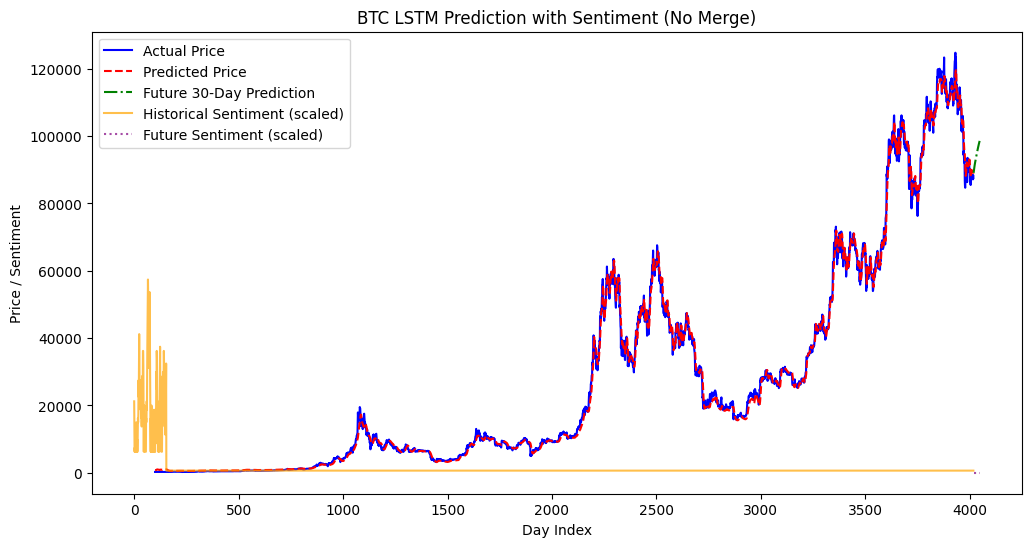

In [187]:
# Ensure Close is numeric
data_close_numeric = data['Close'].astype(float).values

plt.figure(figsize=(12,6))

# Actual BTC price
plt.plot(np.arange(base_days, len(data)), data_close_numeric[base_days:],
         label='Actual Price', color='blue')

# Predicted price (historical)
plt.plot(np.arange(base_days, len(data)), pred_price,
         label='Predicted Price', color='red', linestyle='--')

# Future 30-day prediction
plt.plot(np.arange(len(data), len(data)+future_days), future_price,
         label='Future 30-Day Prediction', color='green', linestyle='-.')

# Historical sentiment (scaled)
plt.plot(np.arange(len(data)), fg_value * max(data_close_numeric),
         label='Historical Sentiment (scaled)', color='orange', alpha=0.7)

# Future sentiment (scaled)
plt.plot(np.arange(len(data), len(data)+future_days), future_sentiment * max(data_close_numeric),
         label='Future Sentiment (scaled)', color='purple', alpha=0.7, linestyle=':')

plt.title("BTC LSTM Prediction with Sentiment (No Merge)")
plt.xlabel("Day Index")
plt.ylabel("Price / Sentiment")
plt.legend()
plt.show()

In [186]:
# Check types and values
print("Type of fg_value:", type(fg_value))
print("First 10 fg_value entries:", fg_value[:10])

print("Type of future_sentiment:", type(future_sentiment))
print("First 10 future_sentiment entries:", future_sentiment[:10])

# Check if any NaNs or strings exist
print("Any NaN in fg_value?", np.isnan(np.array(fg_value, dtype=float)).any())
print("Any NaN in future_sentiment?", np.isnan(np.array(future_sentiment, dtype=float)).any())

# Print first few predicted future prices
print("Future predicted prices:", future_price[:10])


Type of fg_value: <class 'numpy.ndarray'>
First 10 fg_value entries: [0.17 0.11 0.05 0.06 0.05 0.05 0.05 0.05 0.05 0.09]
Type of future_sentiment: <class 'numpy.ndarray'>
First 10 future_sentiment entries: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Any NaN in fg_value? False
Any NaN in future_sentiment? False
Future predicted prices: [89061.13620793 89437.01541859 89893.13892282 90367.13491846
 90825.09987589 91253.20804565 91649.54372237 92016.92848759
 92361.07975649 92690.31376938]


In [188]:
# Save the trained model
model.save('BTC_LSTM_sentiment_model.keras')